In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sbcbinaryformat import Streamer, Writer
import scipy.signal as sg
from pathlib import Path
import pandas as pd
import re
import json
import math

ana_path = "../"
sys.path.insert(0, ana_path)

from GetEvent import GetEvent, GetRun

%matplotlib inline

In [2]:
recon_path = Path("/exp/e961/data/SBC-25-recon/v0.4.2/")
data_path = Path("/exp/e961/data/SBC-25-daqdata/")

# Detector Configurations
- #1, 116K, warm annular
- #2, 116K, cold annular
- #3, 119K
For each, there's
- neutron data
- background data

In [3]:
in_to_cm = 2.54
r_inside = 4.525 * in_to_cm
thickness = 0.2 * in_to_cm
r_outside = r_inside + thickness
z_low = -12*in_to_cm
z_high = (14.72-15.358)*in_to_cm

angle_neck = 1.19367  # angle where the neck and dome meet
n_points = 400
r_neck = 2*in_to_cm
r_neck_inside = r_neck - thickness
x_neck, z_neck = 2.725*in_to_cm, z_high  # center of neck circle
r_dome = 9.4*in_to_cm
r_dome_inside = r_dome - thickness
z_dome = (7.84 - 15.358)*in_to_cm  # center of dome circle
R = r_inside  # for r^2/R

scale_inner = 8.27/9.45
r_neck_inner = r_neck * scale_inner
r_neck_inside_inner = r_neck_inner - thickness
x_neck_inner = x_neck * scale_inner
r_dome_inner = r_dome * scale_inner
r_dome_inside_inner = r_dome_inner - thickness
z_dome_inner = z_dome - 22
z_neck_inner = z_dome_inner + (r_dome_inner - r_neck_inner) * np.sin(angle_neck)

In [4]:
conf1_bg = ["20251113_9", "20251113_10", "20251113_11", "20251114_0", "20251114_1", "20251114_6", "20251114_36", "20251114_37", "20251115_0", 
            "20251115_1", "20251115_2", "20251115_3", "20251115_4", "20251115_5", "20251116_1", "20251116_2", "20251117_0", "20251117_1", 
            "20251126_7", "20251126_8", "20251127_0", "20251127_1", "20251127_2", "20251127_3", "20251127_4", "20251127_5", "20251128_0", 
            "20251128_1", "20251128_2", "20251128_3", "20251128_4", "20251129_0", "20251129_1", "20251129_2", "20251129_3", "20251129_4", 
            "20251129_5", "20251130_0", "20251130_1", "20251130_2", "20251130_3", "20251130_4", "20251130_5"]
conf1_n = ["20260107_3", "20260107_4", "20260107_5", "20260107_6", "20260107_7", "20260108_0", "20260108_1", "20260108_2", "20260108_3", 
                   "20260108_4", "20260108_5", "20260108_6", "20260108_7", "20260108_8", "20260109_0"]
conf1_gamma = ["20251111_2", "20251111_3", "20251111_4", "20251111_5", "20251111_6", "20251111_7", "20251111_8", "20251117_12", "20251117_14", 
               "20251117_15", "20251118_0", "20251118_1", "20251118_2", "20251118_3", "20251118_4", "20251121_5", "20251122_0", "20251122_1", 
               "20251122_2", "20251123_0", "20251123_2", "20251123_3", "20251123_6", "20251123_7", "20251123_8", "20251123_9", "20251123_10", 
               "20251123_11", "20251123_12", "20251123_13", "20251123_14", "20251123_15", "20251123_16", "20251123_17", "20251123_18", 
               "20251123_19", "20251123_20", "20251123_21", "20251123_22", "20251124_0", "20251124_1", "20251124_2", "20251124_3", "20251124_4", 
               "20251124_5", "20251124_6", "20251201_3", "20251201_4", "20251201_5", "20251201_6", "20251210_2", "20251210_3", "20251210_4", 
               "20251210_5", "20251211_0", "20251211_1", "20251211_2", "20251215_3", "20251215_4", "20251215_5", "20251215_6", "20251215_7", 
               "20251216_0", "20251216_1", "20260109_10", "20260109_11", "20260109_12", "20260109_13", "20260109_14", "20260109_15", 
               "20260109_16", "20260109_17", "20260110_0", "20260110_3"]

conf2_bg = ["20260117_0", "20260117_1", "20260117_2", "20260117_3", "20260117_4", "20260118_0", "20260118_1", "20260118_2", "20260118_3", 
            "20260118_4", "20260119_0", "20260119_1", "20260119_2", "20260120_0", "20260120_1"]
conf2_n = ["20260122_3", "20260122_4", "20260122_5", "20260122_6", "20260123_0", "20260123_1", "20260123_2", "20260123_3", "20260123_4", 
           "20260123_8", "20260123_9", "20260123_10", "20260124_0", "20260124_1", "20260124_3", "20260124_4", "20260124_5", "20260125_0", 
           "20260125_1", "20260125_2", "20260125_3", "20260125_4", "20260125_5", "20260125_6", "20260125_7", "20260125_8"]
conf2_gamma = ["20260120_6", "20260120_7", "20260120_9", "20260120_10", "20260120_11", "20260121_1", "20260121_2", "20260121_3", 
               "20260121_4", "20260121_5", "20260122_0", "20260122_1", "20260122_2"]

conf3_bg = ["20260217_7", "20260217_8", "20260217_9", "20260217_10", "20260217_11", "20260217_12", "20260217_13", "20260218_0", "20260218_1", 
              "20260218_2", "20260218_3", "20260218_4", "20260218_5", "20260218_6", "20260218_15", "20260218_16", "20260219_0", "20260219_1", 
              "20260219_2", "20260219_3", "20260219_4", "20260219_5", "20260219_6", "20260219_7", "20260219_8", "20260219_9", "20260219_10", 
              "20260219_11", "20260220_1", "20260220_2", "20260220_3", "20260220_4"]
conf3_n = ["20260205_12", "20260205_13", "20260205_14", "20260205_15", "20260205_16", "20260205_17", "20260205_18", "20260206_0", "20260206_1", 
           "20260206_2", "20260206_3", "20260206_4", "20260206_5", "20260206_6", "20260206_7", "20260213_4", "20260213_5", "20260213_6", 
           "20260213_7", "20260213_8", "20260213_9", "20260214_0", "20260214_1", "20260214_2", "20260214_3", "20260214_4", "20260214_5", 
           "20260214_6", "20260214_7", "20260214_8", "20260214_9", "20260214_10", "20260214_11", "20260214_12", "20260214_13", "20260214_14", 
           "20260215_0", "20260215_1", "20260215_2", "20260215_3", "20260215_4", "20260215_5", "20260215_6", "20260215_7", "20260215_8", 
           "20260215_9", "20260215_10", "20260215_11", "20260215_12", "20260215_13", "20260215_14", "20260216_0", "20260216_1", "20260216_2", 
           "20260216_3", "20260216_4", "20260216_5", "20260216_6", "20260216_7", "20260216_8", "20260216_9", "20260216_10", "20260216_11", 
           "20260216_12", "20260216_13", "20260217_0", "20260217_1", "20260217_2", "20260217_3", "20260217_4", "20260217_5", "20260217_6"]
conf3_gamma = ["20260202_16", "20260202_17", "20260202_18", "20260203_0", "20260203_1", "20260203_2", "20260203_3", "20260203_4", "20260203_5", 
               "20260203_6", "20260203_7", "20260203_8", "20260203_12", "20260206_8", "20260206_9", "20260206_10", "20260206_11", "20260206_12"]

fill2_bg = ["20260330_2", "20260330_3", "20260330_4", "20260330_5"]

In [5]:
def get_bub_3D(runs, one_frame_per_ev=True, reproj_thres=10):
    coords = []
    for run in runs:
        try:
            reco_data = Streamer(os.path.join(recon_path, run, "reco.sbc")).to_dict()
            for ev in np.unique(reco_data["ev"]):
                mask = reco_data["ev"] == ev
                ev_coords = reco_data["coords_3D"][mask]
                reproj_error = reco_data["reprojError"][mask]
                nan_mask = ~np.isnan(ev_coords).any(axis=1)
                filler_mask = (ev_coords > -900).all(axis=1)  # remove filler values like -999 and -1000
                reproj_mask = reproj_error <= reproj_thres
                mask = nan_mask & filler_mask & reproj_mask
                ev_coord = ev_coords[mask]
                
                if len(ev_coord)>0:
                    if one_frame_per_ev:
                        coords.append(ev_coord[0])
                    else:
                        coords.extend(ev_coord)
        except Exception as e:
            print(f"Exception in run {run}: {e}")
            continue
    
    coords = np.array(coords) / 10
    return coords.T

Exception in run 20251117_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251117_1/reco.sbc' does not exist.
Exception in run 20251127_2: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251127_2/reco.sbc' does not exist.
Exception in run 20251128_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251128_1/reco.sbc' does not exist.
Exception in run 20260216_0: File '/exp/e961/data/SBC-25-recon/v0.4.2/20260216_0/reco.sbc' does not exist.
Exception in run 20251111_5: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_5/reco.sbc' does not exist.
Exception in run 20251111_7: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_7/reco.sbc' does not exist.
Exception in run 20251111_8: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_8/reco.sbc' does not exist.


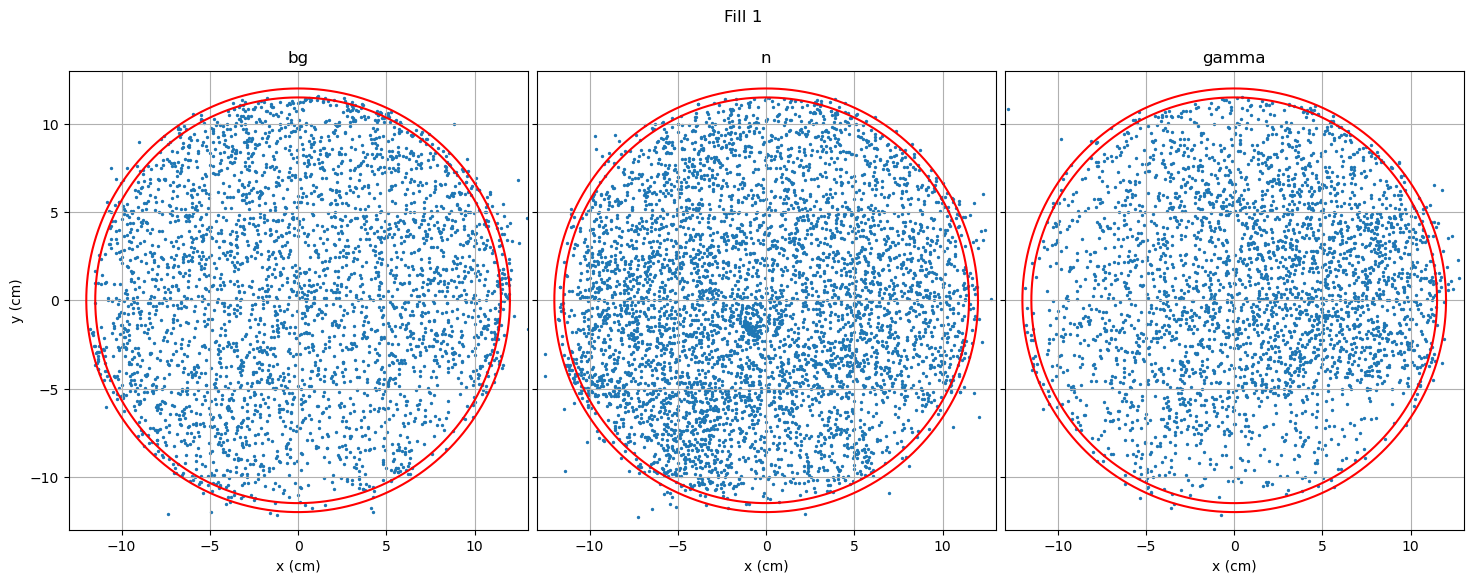

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(18,6), sharey=True)
sources = ["bg", "n", "gamma"]

for i in range(3):
    ax = axs[i]
    s = sources[i]
    pos1 = get_bub_3D(eval(f"conf1_{s}"))
    pos2 = get_bub_3D(eval(f"conf2_{s}"))
    pos3 = get_bub_3D(eval(f"conf3_{s}"))
    all_pos = np.concatenate([pos1, pos2, pos3], axis=1)

    # zeroth degree cut
    all_x, all_y, all_z = all_pos
    mask = (all_z < 5) & (all_z >= -20) # & (np.sqrt(all_x**2 + all_y**2) <= r_inside)
    all_pos = all_pos[:, mask]
    
    ax.scatter(all_pos[0], all_pos[1], s=2)
    
    theta = np.linspace(0, 2*np.pi, n_points)
    ax.plot(r_inside*np.cos(theta), r_inside*np.sin(theta), c='r')
    ax.plot(r_outside*np.cos(theta), r_outside*np.sin(theta), c='r')
    
    ax.set_xlabel("x (cm)")
    ax.set_xlim(-13,13)
    ax.set_ylim(-13,13)
    ax.set_title(f"{s}")
    ax.grid(True)
    ax.set_aspect('equal')

axs[0].set_ylabel("y (cm)")
# axs[2].legend(loc="upper right")
plt.suptitle("Fill 1")
plt.subplots_adjust(wspace=0.02)
plt.show()

Exception in run 20251117_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251117_1/reco.sbc' does not exist.
Exception in run 20251127_2: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251127_2/reco.sbc' does not exist.
Exception in run 20251128_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251128_1/reco.sbc' does not exist.
Exception in run 20260216_0: File '/exp/e961/data/SBC-25-recon/v0.4.2/20260216_0/reco.sbc' does not exist.
Exception in run 20251111_5: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_5/reco.sbc' does not exist.
Exception in run 20251111_7: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_7/reco.sbc' does not exist.
Exception in run 20251111_8: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251111_8/reco.sbc' does not exist.


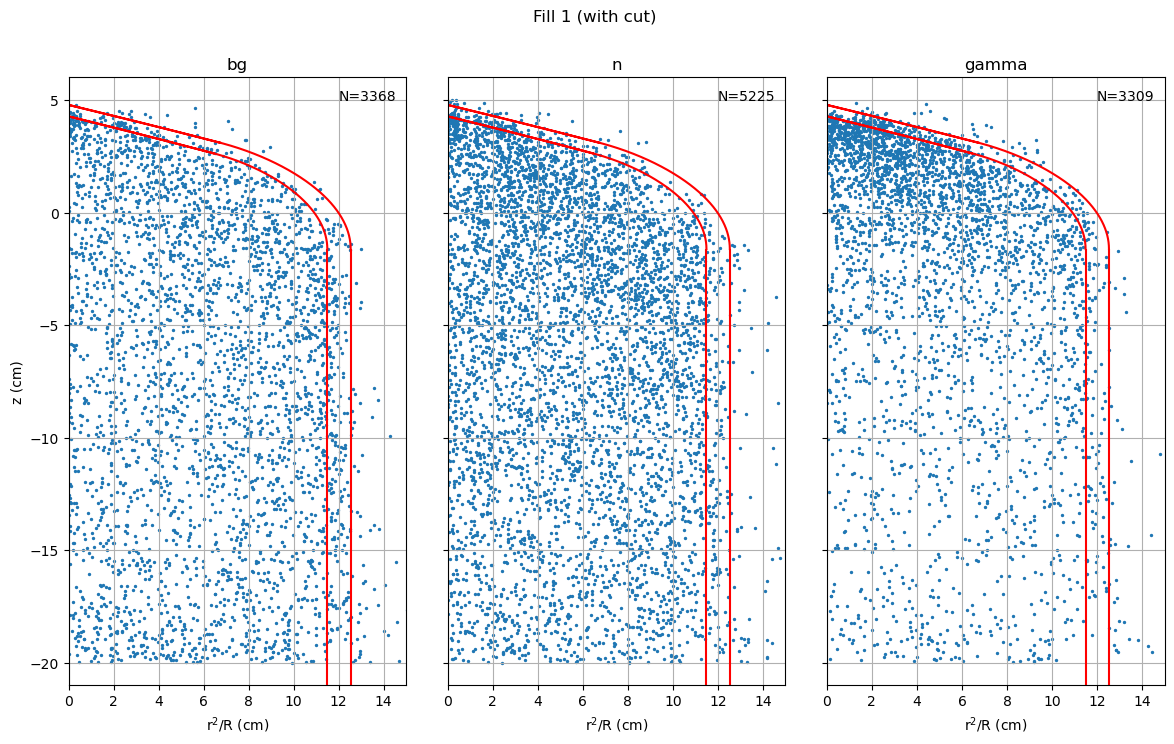

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12,7.5), sharey=True)
sources = ["bg", "n", "gamma"]

for i in range(3):
    ax = axs[i]
    s = sources[i]
    pos1 = get_bub_3D(eval(f"conf1_{s}"))
    pos2 = get_bub_3D(eval(f"conf2_{s}"))
    pos3 = get_bub_3D(eval(f"conf3_{s}"))
    all_pos = np.concatenate([pos1, pos2, pos3], axis=1)

    # zeroth degree cut
    all_x, all_y, all_z = all_pos
    mask = (all_z < 5) & (all_z >= -20)
    all_pos = all_pos[:, mask]
    ax.scatter((all_pos[0]**2 + all_pos[1]**2)/R, all_pos[2], s=2)
    
    ax.vlines(r_inside**2 / R, z_low, z_high,color='r')
    ax.vlines(r_outside**2 / R, z_low, z_high,color='r')
    
    theta = np.linspace(0, angle_neck, n_points)
    x_points = r_neck * np.cos(theta) + x_neck
    z_points = r_neck * np.sin(theta) + z_neck
    ax.plot(x_points**2/R, z_points, c='r')
    
    theta = np.linspace(0, angle_neck, n_points)
    x_points = r_neck_inside * np.cos(theta) + x_neck
    z_points = r_neck_inside * np.sin(theta) + z_neck
    ax.plot(x_points**2/R, z_points, c='r')
    
    theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
    x_points = r_dome * np.cos(theta)
    z_points = r_dome * np.sin(theta) + z_dome
    ax.plot(x_points**2/R, z_points, c='r')
    
    theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
    x_points = r_dome_inside * np.cos(theta)
    z_points = r_dome_inside * np.sin(theta) + z_dome
    ax.plot(x_points**2/R, z_points,c='r')

    ax.text(12, 5, f"N={all_pos.shape[1]}")
    ax.set_xlabel("r$^2$/R (cm)")
    ax.set_xlim(0,15)
    ax.set_ylim(-21,6)
    ax.set_title(f"{s}")
    ax.grid(True)
    ax.set_aspect('equal')

axs[0].set_ylabel("z (cm)")
# axs[2].legend(loc="upper right")
plt.suptitle("Fill 1 (with cut)")
plt.tight_layout()
plt.show()

Exception in run 20251117_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251117_1/reco.sbc' does not exist.
Exception in run 20251127_2: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251127_2/reco.sbc' does not exist.
Exception in run 20251128_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251128_1/reco.sbc' does not exist.


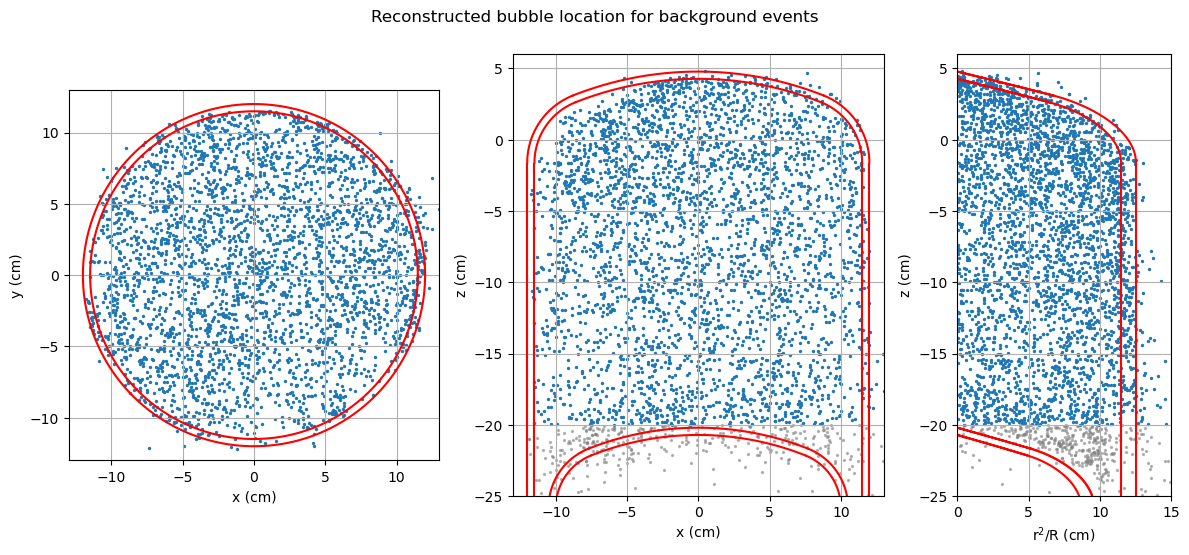

In [8]:
fig, axs = plt.subplot_mosaic(
    [["left", "middle", "right"]],
    figsize=(12, 5.5),
    width_ratios=[26, 26, 15],
)

s = "bg"
pos1 = get_bub_3D(eval(f"conf1_{s}"))
pos2 = get_bub_3D(eval(f"conf2_{s}"))
pos3 = get_bub_3D(eval(f"conf3_{s}"))
all_pos = np.concatenate([pos1, pos2, pos3], axis=1)

# x vs y
ax = axs["left"]

# zeroth degree cut
all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20) # & (np.sqrt(all_x**2 + all_y**2) <= r_inside)
passed_pos = all_pos[:, mask]
ax.scatter(passed_pos[0], passed_pos[1], s=2)

theta = np.linspace(0, 2*np.pi, n_points)
ax.plot(r_inside*np.cos(theta), r_inside*np.sin(theta), c='r')
ax.plot(r_outside*np.cos(theta), r_outside*np.sin(theta), c='r')

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_xlim(-13,13)
ax.set_ylim(-13,13)
ax.grid(True)
ax.set_aspect('equal')

# x vs z
ax = axs["middle"]

# zeroth degree cut
all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20) 
passed_pos = all_pos[:, mask]
ax.scatter(passed_pos[0], passed_pos[2], s=2)

# cut positions
cut_mask = all_z < -20
cut_pos = all_pos[:, cut_mask]
ax.scatter(cut_pos[0], cut_pos[2], s=2, c="gray", alpha=0.5)

ax.vlines(r_inside, z_low, z_high,color='r')
ax.vlines(-r_inside, z_low, z_high,color='r')
ax.vlines(r_outside, z_low, z_high,color='r')
ax.vlines(-r_outside, z_low, z_high,color='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck * np.cos(theta) + x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside * np.cos(theta) + x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck * np.cos(theta) - x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inside * np.cos(theta) - x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome * np.cos(theta)
z_points = r_dome * np.sin(theta) + z_dome
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inside * np.cos(theta)
z_points = r_dome_inside * np.sin(theta) + z_dome
ax.plot(x_points, z_points,c='r')

# inner jar
theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inner * np.cos(theta) - x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inside_inner * np.cos(theta) - x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inner * np.cos(theta)
z_points = r_dome_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inside_inner * np.cos(theta)
z_points = r_dome_inside_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points, z_points,c='r')

ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")

ax.set_xlim(-13, 13)
ax.set_ylim(-25,6)
ax.grid(True)
ax.set_aspect('equal')

# z vs r^2/R
ax = axs["right"]

# zeroth degree cut
all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20) 
passed_pos = all_pos[:, mask]
ax.scatter((passed_pos[0]**2 + passed_pos[1]**2)/R, passed_pos[2], s=2)

# cut positions
cut_mask = all_z < -20
cut_pos = all_pos[:, cut_mask]
ax.scatter((cut_pos[0]**2 + cut_pos[1]**2)/R, cut_pos[2], s=2, c="gray", alpha=0.5)

ax.vlines(r_inside**2 / R, z_low, z_high,color='r')
ax.vlines(r_outside**2 / R, z_low, z_high,color='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck * np.cos(theta) + x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside * np.cos(theta) + x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome * np.cos(theta)
z_points = r_dome * np.sin(theta) + z_dome
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inside * np.cos(theta)
z_points = r_dome_inside * np.sin(theta) + z_dome
ax.plot(x_points**2/R, z_points,c='r')

# inner jar
theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inner * np.cos(theta)
z_points = r_dome_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inside_inner * np.cos(theta)
z_points = r_dome_inside_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points**2/R, z_points,c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

ax.set_xlabel("r$^2$/R (cm)")
ax.set_ylabel("z (cm)")
# ax.tick_params(labelleft=False)

ax.set_xlim(0,15)
ax.set_ylim(-25,6)
ax.grid(True)
ax.set_aspect('equal')

# overall

plt.suptitle("Reconstructed bubble location for background events")
plt.tight_layout()
# plt.savefig("bubble_reconstruction.pdf", bbox_inches="tight")
plt.show()

Exception in run 20251117_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251117_1/reco.sbc' does not exist.
Exception in run 20251127_2: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251127_2/reco.sbc' does not exist.
Exception in run 20251128_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251128_1/reco.sbc' does not exist.


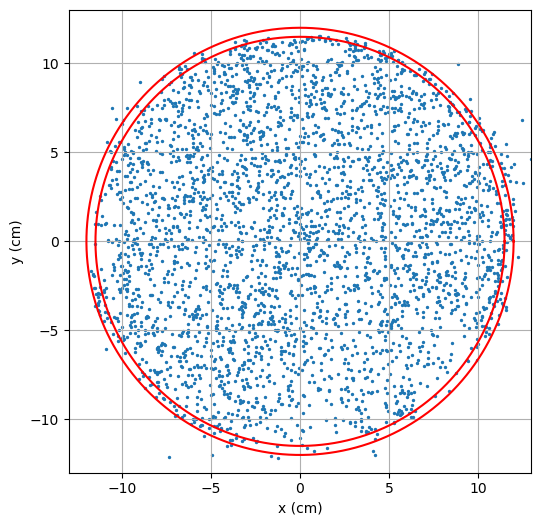

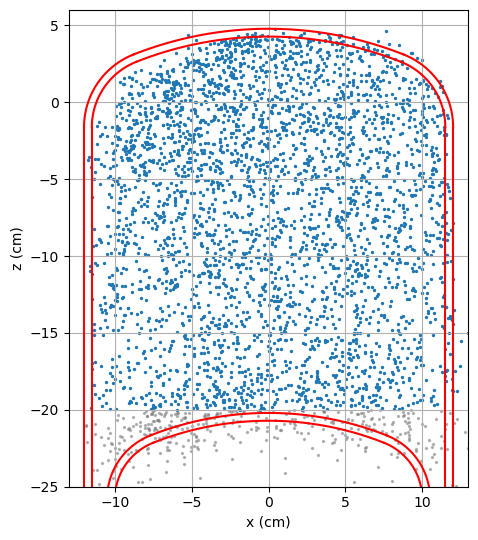

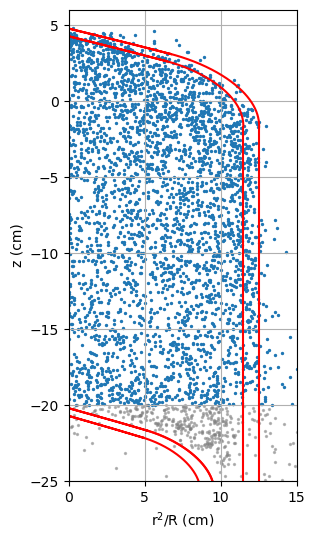

In [9]:
s = "bg"
pos1 = get_bub_3D(eval(f"conf1_{s}"))
pos2 = get_bub_3D(eval(f"conf2_{s}"))
pos3 = get_bub_3D(eval(f"conf3_{s}"))
all_pos = np.concatenate([pos1, pos2, pos3], axis=1)

# Plot 1: x vs y
fig1, ax = plt.subplots(figsize=(5.5, 5.5))

all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20)
passed_pos = all_pos[:, mask]
ax.scatter(passed_pos[0], passed_pos[1], s=2)

theta = np.linspace(0, 2*np.pi, n_points)
ax.plot(r_inside*np.cos(theta), r_inside*np.sin(theta), c='r')
ax.plot(r_outside*np.cos(theta), r_outside*np.sin(theta), c='r')

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_xlim(-13, 13)
ax.set_ylim(-13, 13)
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Plot 2: x vs z
fig2, ax = plt.subplots(figsize=(5.5, 5.5))

all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20)
passed_pos = all_pos[:, mask]
ax.scatter(passed_pos[0], passed_pos[2], s=2)

cut_mask = all_z < -20
cut_pos = all_pos[:, cut_mask]
ax.scatter(cut_pos[0], cut_pos[2], s=2, c="gray", alpha=0.5)

ax.vlines(r_inside, z_low, z_high, color='r')
ax.vlines(-r_inside, z_low, z_high, color='r')
ax.vlines(r_outside, z_low, z_high, color='r')
ax.vlines(-r_outside, z_low, z_high, color='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck * np.cos(theta) + x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside * np.cos(theta) + x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck * np.cos(theta) - x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inside * np.cos(theta) - x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome * np.cos(theta)
z_points = r_dome * np.sin(theta) + z_dome
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inside * np.cos(theta)
z_points = r_dome_inside * np.sin(theta) + z_dome
ax.plot(x_points, z_points, c='r')

# inner jar
theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inner * np.cos(theta) - x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(np.pi - angle_neck, np.pi, n_points)
x_points = r_neck_inside_inner * np.cos(theta) - x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inner * np.cos(theta)
z_points = r_dome_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points, z_points, c='r')

theta = np.linspace(angle_neck, np.pi-angle_neck, n_points)
x_points = r_dome_inside_inner * np.cos(theta)
z_points = r_dome_inside_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points, z_points, c='r')

ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")
ax.set_xlim(-13, 13)
ax.set_ylim(-25, 6)
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Plot 3: z vs r^2/R
fig3, ax = plt.subplots(figsize=(4.0, 5.5))

all_x, all_y, all_z = all_pos
mask = (all_z < 5) & (all_z >= -20)
passed_pos = all_pos[:, mask]
ax.scatter((passed_pos[0]**2 + passed_pos[1]**2)/R, passed_pos[2], s=2)

cut_mask = all_z < -20
cut_pos = all_pos[:, cut_mask]
ax.scatter((cut_pos[0]**2 + cut_pos[1]**2)/R, cut_pos[2], s=2, c="gray", alpha=0.5)

ax.vlines(r_inside**2 / R, z_low, z_high, color='r')
ax.vlines(r_outside**2 / R, z_low, z_high, color='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck * np.cos(theta) + x_neck
z_points = r_neck * np.sin(theta) + z_neck
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside * np.cos(theta) + x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome * np.cos(theta)
z_points = r_dome * np.sin(theta) + z_dome
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inside * np.cos(theta)
z_points = r_dome_inside * np.sin(theta) + z_dome
ax.plot(x_points**2/R, z_points, c='r')

# inner jar
theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inside_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inner * np.cos(theta)
z_points = r_dome_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inside_inner * np.cos(theta)
z_points = r_dome_inside_inner * np.sin(theta) + z_dome_inner
ax.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inner * np.cos(theta) + x_neck_inner
z_points = r_neck_inner * np.sin(theta) + z_neck_inner
ax.plot(x_points**2/R, z_points, c='r')

ax.set_xlabel("r$^2$/R (cm)")
ax.set_ylabel("z (cm)")
ax.set_xlim(0, 15)
ax.set_ylim(-25, 6)
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Distance to Wall

In [10]:
def distance_to_wall(x, y, z):
    r = np.sqrt(x**2 + y**2)
    angle = np.atan2(z - z_dome, r)  # angle based on dome center
    if np.isnan(x) or np.isnan(y) or np.isnan(z):
        return -1
    elif z <= z_high:
        return r_inside - r
    elif 0 <= angle and angle <= angle_neck:
        return r_neck_inside - np.sqrt((r - x_neck)**2 + (z - z_neck)**2)
    elif angle > angle_neck and angle <= np.pi/2:
        return r_dome_inside - np.sqrt(r**2 + (z - z_dome)**2)
    else:
        return -1

def distance_to_wall_array(arr):
    return np.array([distance_to_wall(*pos) for pos in arr])

# MC to get volume profile

In [11]:
N_mc = 200000
z_min, z_max = -20, 5

x_mc = np.random.uniform(-R, R, N_mc)
y_mc = np.random.uniform(-R, R, N_mc)
z_mc = np.random.uniform(z_min, z_max, N_mc)

pos_mc = np.column_stack([x_mc, y_mc, z_mc])
d_mc = distance_to_wall_array(pos_mc)
pos_cut = pos_mc[d_mc > 0]
pos_failed_cut = pos_mc[d_mc <= 0]

In [12]:
bins = 135
d_min = -2
d_max = 11.5
d_edges = np.linspace(d_min, d_max, bins + 1)
d_centers = 0.5 * (d_edges[1:] + d_edges[:-1])

hist, _ = np.histogram(d_mc, bins=d_edges)

total_mc_volume = (2*R)**2 * (z_max - z_min)
mc_scale = total_mc_volume / N_mc  # volume (cm^3) per MC sample
block_volume = hist * mc_scale

In [13]:
conf1_bg_pos = get_bub_3D(conf1_bg)
conf2_bg_pos = get_bub_3D(conf2_bg)
conf3_bg_pos = get_bub_3D(conf3_bg)
all_bg_pos = np.concatenate([conf1_bg_pos, conf2_bg_pos, conf3_bg_pos], axis=1)
all_x, all_y, all_z = all_bg_pos
mask = (all_z < z_max) & (all_z >= z_min) # & (np.sqrt(all_x**2 + all_y**2) <= r_inside)
all_bg_pos = all_bg_pos[:, mask]

d_bg = distance_to_wall_array(all_bg_pos.T)
counts, _ = np.histogram(d_bg, bins=d_edges)

density = counts / block_volume
density_err = np.sqrt(counts) / block_volume

Exception in run 20251117_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251117_1/reco.sbc' does not exist.
Exception in run 20251127_2: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251127_2/reco.sbc' does not exist.
Exception in run 20251128_1: File '/exp/e961/data/SBC-25-recon/v0.4.2/20251128_1/reco.sbc' does not exist.


In [14]:
# define bulk to be d = 3 to 10
d_low, d_high = 5, 11
bulk_mask = (d_centers > d_low) & (d_centers < d_high)   # same region as before

N_bulk_total = counts[bulk_mask].sum()
V_bulk_total = block_volume[bulk_mask].sum()

bulk_density = N_bulk_total / V_bulk_total
bulk_density_err = np.sqrt(N_bulk_total) / V_bulk_total   # simple Poisson error on the summed count

print(f"bulk density = {bulk_density:.4f} +/- {bulk_density_err:.4f} bubbles/cm^3")

bulk density = 0.2585 +/- 0.0102 bubbles/cm^3


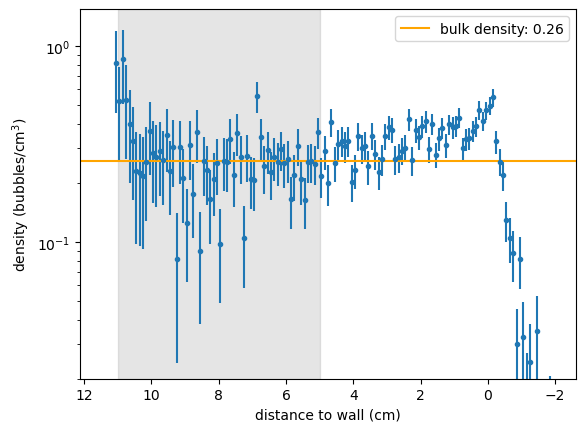

In [15]:
expected_counts = bulk_density * block_volume
plt.errorbar(d_centers, density, yerr=density_err, fmt='.')
plt.axhline(y=bulk_density, c="orange", label=f"bulk density: {bulk_density:.2f}")
plt.axvspan(d_low, d_high, color="gray", alpha=0.2)
plt.xlabel('distance to wall (cm)')
plt.ylabel('density (bubbles/cm$^3$)')
plt.yscale("log")
plt.ylim(2e-2, )
plt.legend()
plt.gca().invert_xaxis()
plt.show()

In [16]:
from scipy.stats import chi2

def obs_exp_within(d_low, d_high):
    mask = (d_low <= d_edges[:-1]) & (d_edges[:-1] < d_high)
    N_obs = counts[mask].sum()
    N_exp = expected_counts[mask].sum()
    return N_obs, N_exp

def poisson_upper_limit_on_total(N_obs, CL=0.9):
    return 0.5 * chi2.ppf(CL, df=2*(N_obs + 1))

def poisson_significance(N_obs, N_exp):
    if N_obs <= N_exp:
        return 0.0
    return np.sqrt(2 * (N_obs * np.log(N_obs / N_exp) - (N_obs - N_exp)))

In [17]:
for d_cut in [-1, 0, 1, 2, 3, 4, 5, 6]:
    N_obs, N_exp = obs_exp_within(d_cut-1, d_cut)
    mu_up_total = poisson_upper_limit_on_total(N_obs, CL=0.9)
    s_up = max(mu_up_total - N_exp, 0)   # upper limit on wall counts
    
    excess = N_obs - N_exp
    excess_err = np.sqrt(N_obs)
    sigma = poisson_significance(N_obs, N_exp)
    print(f"{d_cut-1} < d < {d_cut}cm: N_obs={N_obs}, N_exp={N_exp:.2f}, "
          # f"90% CL upper limit on excess = {s_up:.2f}, "
          f"excess: {excess:.2f} +/- {excess_err:.2f}, significance: {sigma:.2f}")

-2 < d < -1cm: N_obs=17, N_exp=283.95, excess: -266.95 +/- 4.12, significance: 0.00
-1 < d < 0cm: N_obs=365, N_exp=388.92, excess: -23.92 +/- 19.10, significance: 0.00
0 < d < 1cm: N_obs=713, N_exp=470.66, excess: 242.34 +/- 26.70, significance: 10.37
1 < d < 2cm: N_obs=575, N_exp=413.50, excess: 161.50 +/- 23.98, significance: 7.49
2 < d < 3cm: N_obs=445, N_exp=350.27, excess: 94.73 +/- 21.10, significance: 4.86
3 < d < 4cm: N_obs=332, N_exp=295.28, excess: 36.72 +/- 18.22, significance: 2.09
4 < d < 5cm: N_obs=274, N_exp=247.33, excess: 26.67 +/- 16.55, significance: 1.67
5 < d < 6cm: N_obs=182, N_exp=189.20, excess: -7.20 +/- 13.49, significance: 0.00


In [18]:
print(f"d_cut (cm)\tV_rm\tbub_rm\tbub_rm/V_rm")
for d_cut in range(1,6):
    V_total_jar = pos_cut.shape[0] * mc_scale
    
    mc_mask = d_edges[:-1] < d_cut
    V_removed = block_volume[mc_mask].sum()
    V_removed_frac = V_removed / V_total_jar
    
    data_mask = d_edges[:-1] < d_cut
    N_removed = counts[data_mask].sum()
    N_removed_frac = N_removed / counts.sum()
    
    print(f"{d_cut}, \t\t"
          f"{V_removed_frac*100:.1f}%, \t"
          f"{N_removed_frac*100:.1f}%, \t"
          f"{N_removed_frac/V_removed_frac:.2f}")

d_cut (cm)	V_rm	bub_rm	bub_rm/V_rm
1, 		47.3%, 	32.6%, 	0.69
2, 		64.4%, 	49.7%, 	0.77
3, 		78.9%, 	62.9%, 	0.80
4, 		91.1%, 	72.8%, 	0.80
5, 		101.3%, 	80.9%, 	0.80


# MC Smearing (gamma distribution)

Add an error with a gamma distribution and random angle to the MC x,y,z

In [19]:
N_mc = 4641
# N_mc = 100000
z_min, z_max = -20, 5

x_mc = np.random.uniform(-R, R, N_mc)
y_mc = np.random.uniform(-R, R, N_mc)
z_mc = np.random.uniform(z_min, z_max, N_mc)

pos_mc = np.column_stack([x_mc, y_mc, z_mc])
d_mc = distance_to_wall_array(pos_mc)
pos_cut = pos_mc[d_mc > 0]
pos_failed_cut = pos_mc[d_mc <= 0]

In [20]:
# Dan's 3D reconstruction error statistics (DocDB 1978)
mean = 0.1931 * in_to_cm
median = 0.1647 * in_to_cm
std = 0.1272 * in_to_cm
var = std**2

shape = mean**2 / var
scale = var / mean

In [21]:
rng = np.random.default_rng(3)
r = rng.gamma(shape, scale, N_mc)
phi = rng.uniform(0, 2 * np.pi, N_mc)
theta = np.arccos(rng.uniform(-1, 1, N_mc))

dx = r * np.sin(theta) * np.cos(phi)
dy = r * np.sin(theta) * np.sin(phi)
dz = r * np.cos(theta)

x_smeared = x_mc + dx
y_smeared = y_mc + dy
z_smeared = z_mc + dz

In [22]:
pos_smeared = np.column_stack([x_smeared, y_smeared, z_smeared])
d_smeared = distance_to_wall_array(pos_smeared)

hist_smeared, _ = np.histogram(d_smeared, bins=d_edges)

total_mc_volume  = (2*R)**2 * (z_max - z_min)
mc_scale_smeared = total_mc_volume / N_mc
block_volume_smeared = hist_smeared * mc_scale_smeared

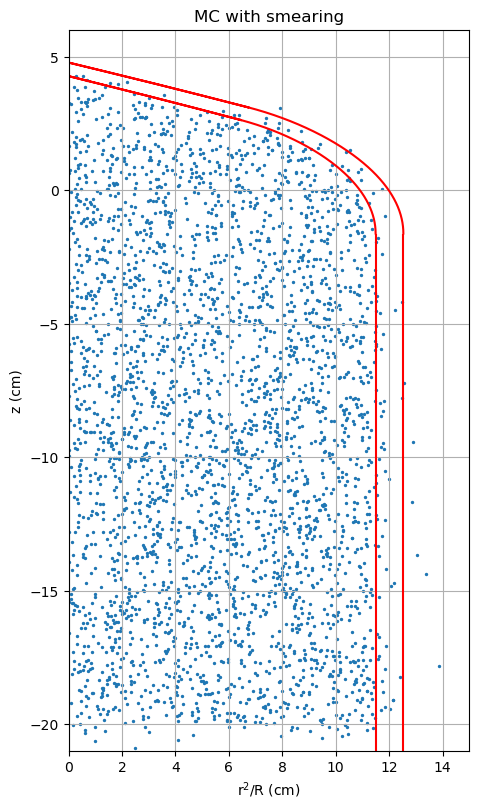

In [23]:
pos_smeared_cut = pos_smeared[d_mc>0]
pos_smeared_failed_cut = pos_smeared[d_mc<=0]

plt.figure(figsize=(8,8))
# plt.scatter((pos_smeared_failed_cut[:, 0]**2 + pos_smeared_failed_cut[:, 1]**2)/R, pos_smeared_failed_cut[:, 2], s=2, 
#             label="outside", alpha=1, color="tab:orange")
plt.scatter((pos_smeared_cut[:, 0]**2 + pos_smeared_cut[:, 1]**2)/R, pos_smeared_cut[:, 2], s=2, 
            label="inside", alpha=1, color="tab:blue")

plt.vlines(r_inside**2 / R, z_low, z_high,color='r')
plt.vlines(r_outside**2 / R, z_low, z_high,color='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck * np.cos(theta) + x_neck
z_points = r_neck * np.sin(theta) + z_neck
plt.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(0, angle_neck, n_points)
x_points = r_neck_inside * np.cos(theta) + x_neck
z_points = r_neck_inside * np.sin(theta) + z_neck
plt.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome * np.cos(theta)
z_points = r_dome * np.sin(theta) + z_dome
plt.plot(x_points**2/R, z_points, c='r')

theta = np.linspace(angle_neck, np.pi - angle_neck, n_points)
x_points = r_dome_inside * np.cos(theta)
z_points = r_dome_inside * np.sin(theta) + z_dome
plt.plot(x_points**2/R, z_points,c='r')

plt.xlim(0,15)
plt.ylim(-21,6)
plt.grid(True)

plt.xlabel("r$^2$/R (cm)")
plt.ylabel("z (cm)")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.title("MC with smearing")
plt.show()

In [24]:
bins = 135
d_min = -2
d_max = 11.5
d_edges = np.linspace(d_min, d_max, bins + 1)
d_centers = 0.5 * (d_edges[1:] + d_edges[:-1])

hist, _ = np.histogram(d_mc, bins=d_edges)

total_mc_volume = (2*R)**2 * (z_max - z_min)
mc_scale = total_mc_volume / N_mc  # volume (cm^3) per MC sample
count_scale = 4641/N_mc
block_volume = hist * mc_scale / count_scale

In [25]:
d_smeared = distance_to_wall_array(pos_smeared_cut)
counts, _ = np.histogram(d_smeared, bins=d_edges)

density = counts / block_volume
density_err = np.sqrt(counts) / block_volume

/tmp/ipykernel_2474/3152921758.py:4: RuntimeWarning: divide by zero encountered in divide
  density = counts / block_volume
/tmp/ipykernel_2474/3152921758.py:5: RuntimeWarning: divide by zero encountered in divide
  density_err = np.sqrt(counts) / block_volume


In [26]:
# define bulk to be d = 3 to 10
d_low, d_high = 5, 11
bulk_mask = (d_centers > d_low) & (d_centers < d_high)   # same region as before

N_bulk_total = counts[bulk_mask].sum()
V_bulk_total = block_volume[bulk_mask].sum()

bulk_density = N_bulk_total / V_bulk_total
bulk_density_err = np.sqrt(N_bulk_total) / V_bulk_total   # simple Poisson error on the summed count

print(f"bulk density = {bulk_density:.4f} +/- {bulk_density_err:.4f} bubbles/cm^3")

bulk density = 0.3493 +/- 0.0119 bubbles/cm^3


/home/zsheng/.conda/envs/analysis/lib/python3.13/site-packages/matplotlib/axes/_axes.py:3831: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


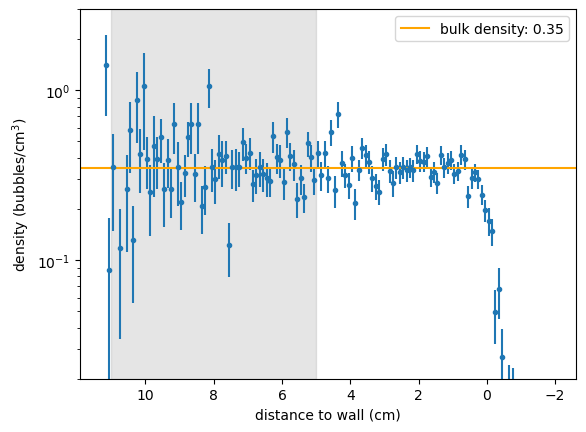

In [27]:
expected_counts = bulk_density * block_volume
plt.errorbar(d_centers, density, yerr=density_err, fmt='.')
plt.axhline(y=bulk_density, c="orange", label=f"bulk density: {bulk_density:.2f}")
plt.axvspan(d_low, d_high, color="gray", alpha=0.2)
plt.xlabel('distance to wall (cm)')
plt.ylabel('density (bubbles/cm$^3$)')
plt.yscale("log")
plt.ylim(2e-2, 3e0)
plt.legend()
plt.gca().invert_xaxis()
plt.show()

In [28]:
for d_cut in [-1, 0, 1, 2, 3, 4, 5, 6]:
    N_obs, N_exp = obs_exp_within(d_cut-1, d_cut)
    mu_up_total = poisson_upper_limit_on_total(N_obs, CL=0.9)
    s_up = max(mu_up_total - N_exp, 0)   # upper limit on wall counts
    
    excess = N_obs - N_exp
    excess_err = np.sqrt(N_obs)
    sigma = poisson_significance(N_obs, N_exp)
    print(f"{d_cut-1} < d < {d_cut}cm: N_obs={N_obs}, N_exp={N_exp:.2f}, "
          # f"90% CL upper limit on excess = {s_up:.2f}, "
          f"excess: {excess:.2f} +/- {excess_err:.2f}, significance: {sigma:.2f}")

-2 < d < -1cm: N_obs=1, N_exp=367.87, excess: -366.87 +/- 1.00, significance: 0.00
-1 < d < 0cm: N_obs=88, N_exp=564.73, excess: -476.73 +/- 9.38, significance: 0.00
0 < d < 1cm: N_obs=560, N_exp=654.21, excess: -94.21 +/- 23.66, significance: 0.00
1 < d < 2cm: N_obs=551, N_exp=535.90, excess: 15.10 +/- 23.47, significance: 0.65
2 < d < 3cm: N_obs=468, N_exp=464.31, excess: 3.69 +/- 21.63, significance: 0.17
3 < d < 4cm: N_obs=394, N_exp=406.65, excess: -12.65 +/- 19.85, significance: 0.00
4 < d < 5cm: N_obs=320, N_exp=303.25, excess: 16.75 +/- 17.89, significance: 0.95
5 < d < 6cm: N_obs=268, N_exp=275.41, excess: -7.41 +/- 16.37, significance: 0.00


In [29]:
# Cs by pressure
cs_run = ["20251111_2", "20251111_3", "20251111_4", "20251111_5", "20251111_6", "20251111_7", "20251111_8", "20251117_12", 
          "20251117_14", "20251117_15", "20251118_0", "20251118_1", "20251118_2", "20251118_3", "20251118_4", "20251201_3", 
          "20251201_4", "20251201_5", "20251210_2", "20251210_3", "20251210_4", "20251210_5", "20251211_0", "20251211_1", 
          "20251211_2", "20260109_10", "20260109_11", "20260109_12", "20260109_13", "20260109_14", "20260109_15", "20260109_16", 
          "20260109_17", "20260110_0", "20260110_3"]
cs2_run = ["20260120_6", "20260120_7", "20260120_9", "20260120_10", "20260120_11", "20260121_1"]
cs3_run = ["20260202_16", "20260202_17", "20260202_18", "20260203_0", "20260203_1", "20260203_2", "20260203_3",
           "20260203_4", "20260203_5", "20260203_6", "20260203_7", "20260203_8"]
co_run = ["20251215_3", "20251215_4", "20251215_5", "20251215_6", "20251215_7", "20251216_0", "20251216_1", "20260121_2", "20260121_3", 
          "20260121_4", "20260121_5", "20260122_0", "20260122_1", "20260122_2", "20260203_10", "20260203_11", "20260203_12"]
co2_run = ["20260121_2", "20260121_3", "20260121_4", "20260121_5",
           "20260122_0", "20260122_1", "20260122_2"]
co3_run = ["20260206_8", "20260206_9", "20260206_10", "20260206_11", "20260206_12",
           "20260220_5", "20260220_6", "20260220_7", "20260220_8", "20260220_9",
           "20260220_10", "20260220_11", "20260220_12", "20260220_13",
           "20260221_0", "20260221_1", "20260221_2", "20260221_3", "20260221_4",
           "20260221_5", "20260221_6", "20260221_7", "20260221_8", "20260221_9",
           "20260221_10", "20260221_11", "20260221_12", "20260221_13", "20260221_14",
           "20260222_0", "20260222_1", "20260222_2", "20260222_3", "20260222_4",
           "20260222_5", "20260222_6", "20260222_7", "20260222_8", "20260222_9",
           "20260222_10", "20260222_11", "20260222_12", "20260222_13", "20260222_14",
           "20260223_0", "20260223_1", "20260223_2", "20260223_3", "20260223_4",
           "20260223_5", "20260223_6", "20260223_7", "20260223_8", "20260223_9",
           "20260223_10", "20260223_11",
           "20260224_0", "20260224_1", "20260224_2", "20260224_3", "20260224_4",
           "20260224_5", "20260224_6", "20260224_7", "20260224_8", "20260224_9",
           "20260224_10", "20260224_11", "20260224_12", "20260224_13",
           "20260225_0", "20260225_1", "20260225_2", "20260225_3", "20260225_4",
           "20260225_6", "20260225_7", "20260225_8", "20260225_9", "20260225_10",
           "20260225_11", "20260225_12", "20260225_13", "20260225_14", "20260225_15", "20260225_16",
           "20260226_0", "20260226_1", "20260226_2", "20260226_3", "20260226_4",
           "20260226_5", "20260226_6", "20260226_7", "20260226_8",
           "20260227_0", "20260227_1", "20260227_2", "20260227_3", "20260227_4",
           "20260227_5", "20260227_6", "20260227_7"]

# 90% limit

In [30]:
from scipy.stats import poisson
from scipy.optimize import brentq

def upper_limit_signal(n_obs, bkg, CL=0.90):
    alpha = 1 - CL

    def f(s):
        return poisson.cdf(n_obs, bkg + s) - alpha

    if f(0) < 0:
        return 0

    return brentq(f, 0, 1000)

In [31]:
for d_cut in [-1, 0, 1, 2, 3, 4, 5, 6]:
    N_obs, N_exp = obs_exp_within(d_cut-1, d_cut)
    mu = poisson_upper_limit_on_total(N_obs)
    s90 = max(mu - N_exp, 0)
    
    excess = N_obs - N_exp
    excess_err = np.sqrt(N_obs)
    sigma = poisson_significance(N_obs, N_exp)
    print(f"{d_cut-1} < d < {d_cut}cm: N_obs={N_obs}, N_exp={N_exp:.2f}, "
          f"90% CL upper limit on excess = {s90:.2f}, "
          f"excess: {excess:.2f} +/- {excess_err:.2f}, significance: {sigma:.2f}")

-2 < d < -1cm: N_obs=1, N_exp=367.87, 90% CL upper limit on excess = 0.00, excess: -366.87 +/- 1.00, significance: 0.00
-1 < d < 0cm: N_obs=88, N_exp=564.73, 90% CL upper limit on excess = 0.00, excess: -476.73 +/- 9.38, significance: 0.00
0 < d < 1cm: N_obs=560, N_exp=654.21, 90% CL upper limit on excess = 0.00, excess: -94.21 +/- 23.66, significance: 0.00
1 < d < 2cm: N_obs=551, N_exp=535.90, 90% CL upper limit on excess = 46.42, excess: 15.10 +/- 23.47, significance: 0.65
2 < d < 3cm: N_obs=468, N_exp=464.31, 90% CL upper limit on excess = 32.65, excess: 3.69 +/- 21.63, significance: 0.17
3 < d < 4cm: N_obs=394, N_exp=406.65, 90% CL upper limit on excess = 14.03, excess: -12.65 +/- 19.85, significance: 0.00
4 < d < 5cm: N_obs=320, N_exp=303.25, 90% CL upper limit on excess = 40.92, excess: 16.75 +/- 17.89, significance: 0.95
5 < d < 6cm: N_obs=268, N_exp=275.41, 90% CL upper limit on excess = 14.82, excess: -7.41 +/- 16.37, significance: 0.00


In [32]:
N_obs, N_exp = obs_exp_within(0, 12)
mu_tot = poisson_upper_limit_on_total(N_obs, CL=0.9)
s_tot = max(mu_tot - N_exp, 0)
print(s_tot)

3.042746876869842
